DADOS DOS MICROSSERVIÇOS (ILUSTRATIVOS):
servico  valor  ram  cpu
   MS01     24  2.0  1.0
   MS02     18  1.5  0.5
   MS03     35  3.5  1.5
   MS04     29  2.0  1.0
   MS05     14  1.0  0.5
   MS06     40  4.0  2.0
   MS07     22  1.5  1.0
   MS08     31  3.0  1.5
   MS09     16  1.0  0.5
   MS10     37  3.5  1.5
   MS11     26  2.5  1.0
   MS12     20  1.5  1.0
   MS13     33  3.0  1.5
   MS14     15  1.0  0.5
   MS15     28  2.0  1.0

MELHORES SOLUÇÕES VIÁVEIS POR ESTRATÉGIA:
estrategia  repeticao  valor  ram  cpu      cromossomo                                                   servicos
         A          0  212.0 16.0  8.0 110110101011011 MS01, MS02, MS04, MS05, MS07, MS09, MS11, MS12, MS14, MS15
         B          0  212.0 16.0  8.0 110110101011011 MS01, MS02, MS04, MS05, MS07, MS09, MS11, MS12, MS14, MS15

MÉTRICAS FINAIS MÉDIAS EM 20 EXECUÇÕES:
estrategia  geracao  fitness_medio  fitness_dp_entre_execucoes  dp_populacional_medio  diversidade_media  melhor_viavel_medio
       

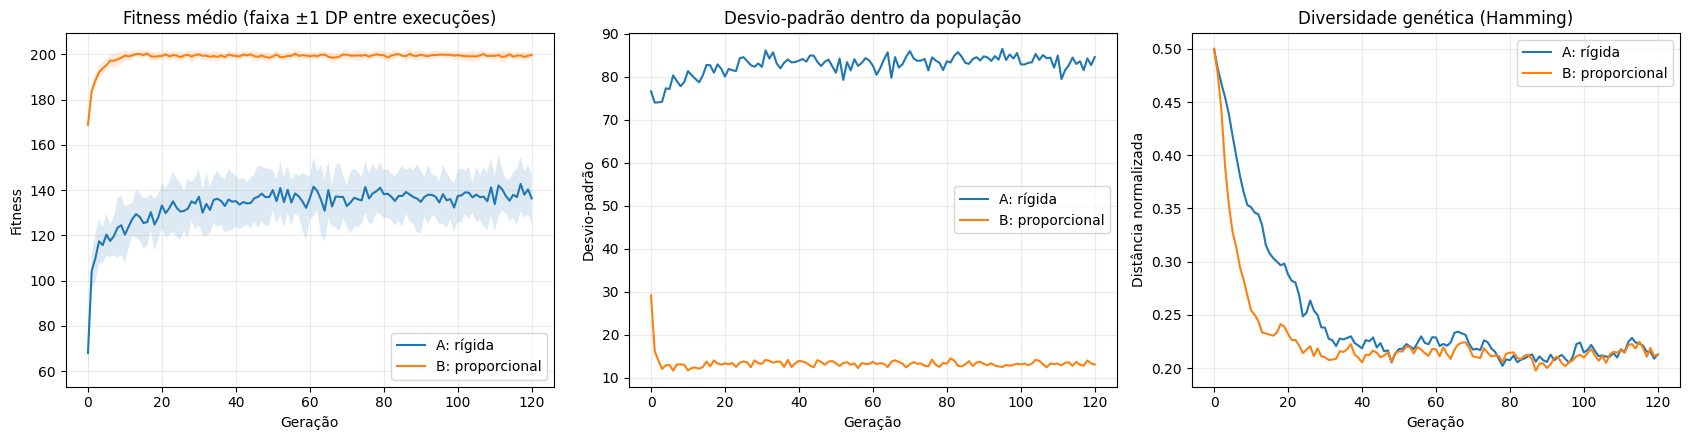


ÓTIMO EXATO (apenas validação, não usado pelo AG): 212.0
Serviços: MS01, MS02, MS04, MS05, MS07, MS09, MS11, MS12, MS14, MS15
RAM: 16.0 CPU: 8.0

CONCLUSÃO BASEADA NAS EXECUÇÕES:
Maior diversidade genética final média: A
Melhor valor viável: empate entre A e B: 212.0
Atenção: desvio-padrão de fitness não é, sozinho, medida de diversidade genética.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


SERVICOS = pd.DataFrame({
    'servico': [f'MS{i:02d}' for i in range(1,16)],
    'valor': [24,18,35,29,14,40,22,31,16,37,26,20,33,15,28],
    'ram':   [2.0,1.5,3.5,2.0,1.0,4.0,1.5,3.0,1.0,3.5,2.5,1.5,3.0,1.0,2.0],
    'cpu':   [1.0,0.5,1.5,1.0,0.5,2.0,1.0,1.5,0.5,1.5,1.0,1.0,1.5,0.5,1.0]
})
RAM_MAX, CPU_MAX = 16.0, 8.0
TAM_POP, GERACOES, TORNEIO = 60, 120, 3
TAXA_CROSS, TAXA_MUT, ELITISMO = 0.85, 1/15, 2
REPETICOES, SEED = 20, 42

LAMBDA = 100.0

def metricas(ind):
    x=np.asarray(ind)
    return (float(x @ SERVICOS.valor.to_numpy()),
            float(x @ SERVICOS.ram.to_numpy()),
            float(x @ SERVICOS.cpu.to_numpy()))

def viavel(ind):
    _,ram,cpu=metricas(ind)
    return ram <= RAM_MAX+1e-9 and cpu <= CPU_MAX+1e-9

def fitness(ind, estrategia):
    valor,ram,cpu=metricas(ind)
    if estrategia=='A':
        return valor if viavel(ind) else 0.0
    excesso=max(0,ram-RAM_MAX)/RAM_MAX + max(0,cpu-CPU_MAX)/CPU_MAX
    return max(0.0, valor-LAMBDA*excesso)

def diversidade(pop):

    n=len(pop)
    if n<2: return 0.0
    pares=np.triu_indices(n,1)
    return float(np.not_equal(pop[pares[0]],pop[pares[1]]).mean())

def torneio(pop, fits, rng):
    candidatos=rng.choice(len(pop),size=TORNEIO,replace=False)
    return pop[candidatos[np.argmax(fits[candidatos])]].copy()

def cruzar(a,b,rng):
    if rng.random()<TAXA_CROSS:
        ponto=int(rng.integers(1,len(a)))
        return np.r_[a[:ponto],b[ponto:]],np.r_[b[:ponto],a[ponto:]]
    return a.copy(),b.copy()

def mutar(ind,rng):
    mascara=rng.random(len(ind))<TAXA_MUT
    ind[mascara]=1-ind[mascara]
    return ind

def executar(estrategia, seed):
    rng=np.random.default_rng(seed)
    pop=rng.integers(0,2,size=(TAM_POP,15),dtype=np.int8)
    historico=[]
    melhor_viavel=None
    melhor_valor=-1
    for geracao in range(GERACOES+1):
        fits=np.array([fitness(ind,estrategia) for ind in pop])
        for ind in pop:
            if viavel(ind):
                valor,_,_=metricas(ind)
                if valor>melhor_valor:
                    melhor_valor=valor
                    melhor_viavel=ind.copy()
        historico.append({'geracao':geracao,'fitness_medio':float(fits.mean()),
                          'fitness_dp':float(fits.std(ddof=0)),
                          'fitness_max':float(fits.max()),
                          'diversidade':diversidade(pop),
                          'melhor_viavel':melhor_valor if melhor_viavel is not None else 0})
        if geracao==GERACOES: break
        elite=pop[np.argsort(fits)[-ELITISMO:]].copy()
        nova=list(elite)
        while len(nova)<TAM_POP:
            pai1=torneio(pop,fits,rng); pai2=torneio(pop,fits,rng)
            f1,f2=cruzar(pai1,pai2,rng)
            nova.append(mutar(f1,rng))
            if len(nova)<TAM_POP: nova.append(mutar(f2,rng))
        pop=np.asarray(nova,dtype=np.int8)
    return pd.DataFrame(historico),melhor_viavel

registros=[]; solucoes=[]
for estrategia in ('A','B'):
    for rep in range(REPETICOES):
        hist,sol=executar(estrategia,SEED+rep)
        hist['estrategia']=estrategia; hist['repeticao']=rep
        registros.append(hist)
        if sol is not None:
            valor,ram,cpu=metricas(sol)
            solucoes.append({'estrategia':estrategia,'repeticao':rep,'valor':valor,
                             'ram':ram,'cpu':cpu,'cromossomo':''.join(map(str,sol.tolist())),
                             'servicos':', '.join(SERVICOS.servico[sol==1])})
resultados=pd.concat(registros,ignore_index=True)
solucoes=pd.DataFrame(solucoes)
resumo=(resultados.groupby(['estrategia','geracao'],as_index=False)
        .agg(fitness_medio=('fitness_medio','mean'),
             fitness_dp_entre_execucoes=('fitness_medio','std'),
             dp_populacional_medio=('fitness_dp','mean'),
             diversidade_media=('diversidade','mean'),
             melhor_viavel_medio=('melhor_viavel','mean')))
melhores=(solucoes.sort_values(['estrategia','valor'],ascending=[True,False])
          .drop_duplicates('estrategia'))
print('DADOS DOS MICROSSERVIÇOS (ILUSTRATIVOS):')
print(SERVICOS.to_string(index=False))
print('\nMELHORES SOLUÇÕES VIÁVEIS POR ESTRATÉGIA:')
print(melhores.to_string(index=False))
print('\nMÉTRICAS FINAIS MÉDIAS EM 20 EXECUÇÕES:')
print(resumo[resumo.geracao==GERACOES].to_string(index=False))

fig,axes=plt.subplots(1,3,figsize=(17,4.5))
for estrategia,rotulo in [('A','A: rígida'),('B','B: proporcional')]:
    df=resumo[resumo.estrategia==estrategia]
    x=df.geracao.to_numpy()
    y=df.fitness_medio.to_numpy(); dp=df.fitness_dp_entre_execucoes.fillna(0).to_numpy()
    axes[0].plot(x,y,label=rotulo)
    axes[0].fill_between(x,y-dp,y+dp,alpha=.15)
    axes[1].plot(x,df.dp_populacional_medio.to_numpy(),label=rotulo)
    axes[2].plot(x,df.diversidade_media.to_numpy(),label=rotulo)
for ax,titulo,ylabel in zip(axes,['Fitness médio (faixa ±1 DP entre execuções)',
                                  'Desvio-padrão dentro da população','Diversidade genética (Hamming)'],
                                 ['Fitness','Desvio-padrão','Distância normalizada']):
    ax.set(title=titulo,xlabel='Geração',ylabel=ylabel);ax.grid(alpha=.25);ax.legend()
fig.tight_layout();fig.savefig('lab02_comparacao.png',dpi=170)
resultados.to_csv('lab02_historico.csv',index=False)
resumo.to_csv('lab02_resumo.csv',index=False)
solucoes.to_csv('lab02_solucoes.csv',index=False)
plt.show()

melhor_exato=None; valor_exato=-1
for mascara in range(1<<15):
    ind=np.array([(mascara>>i)&1 for i in range(15)],dtype=np.int8)
    if viavel(ind):
        valor,ram,cpu=metricas(ind)
        if valor>valor_exato:
            valor_exato=valor; melhor_exato=(ind,ram,cpu)
print('\nÓTIMO EXATO (apenas validação, não usado pelo AG):',valor_exato)
print('Serviços:',', '.join(SERVICOS.servico[melhor_exato[0]==1]))
print('RAM:',melhor_exato[1],'CPU:',melhor_exato[2])
print('\nCONCLUSÃO BASEADA NAS EXECUÇÕES:')
final=resumo[resumo.geracao==GERACOES].set_index('estrategia')
div=final.diversidade_media.idxmax()
print('Maior diversidade genética final média:',div)
val=melhores.set_index('estrategia').valor
if val.nunique()==1: print('Melhor valor viável: empate entre A e B:',val.iloc[0])
else: print('Maior valor viável encontrado:',val.idxmax(),val.max())
print('Atenção: desvio-padrão de fitness não é, sozinho, medida de diversidade genética.')
